<a href="https://colab.research.google.com/github/Src-Bhavesh/DS-Basics/blob/main/12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Finance Data Mini Project**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_excel("financial_loan.xlsx")
df=pd.DataFrame(df)
print(df.head())

        id address_state application_type emp_length              emp_title  \
0  1077430            GA       INDIVIDUAL   < 1 year                  Ryder   
1  1072053            CA       INDIVIDUAL    9 years         MKC Accounting   
2  1069243            CA       INDIVIDUAL    4 years  Chemat Technology Inc   
3  1041756            TX       INDIVIDUAL   < 1 year    barnes distribution   
4  1068350            IL       INDIVIDUAL  10+ years          J&J Steel Inc   

  grade home_ownership issue_date last_credit_pull_date last_payment_date  \
0     C           RENT 2021-02-11            2021-09-13        2021-04-13   
1     E           RENT 2021-01-01            2021-12-14        2021-01-15   
2     C           RENT 2021-01-05            2021-12-12        2021-01-09   
3     B       MORTGAGE 2021-02-25            2021-12-12        2021-03-12   
4     A       MORTGAGE 2021-01-01            2021-12-14        2021-01-15   

   ... sub_grade        term  verification_status annual_incom

Meta Data

In [5]:
print(df.shape)

(38576, 24)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [7]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


NO. of loan applicant

In [27]:
d=len(df['id'].unique())
d

# df['id'].nunique()


38576

Loan taken this month

In [46]:

d = pd.Timestamp.today()
m=d.month
current_date = d.day
app_curr_month = df[(df['issue_date'].dt.month==m) & (df['issue_date'].dt.day<=current_date)]
num_app_curr_month = len(app_curr_month['id'].unique())
num_app_curr_month




3184

Loan taken till this day this month

In [55]:
current_date = pd.Timestamp.today()
current_month = current_date.month
current_day = current_date.day

app_curr_month = df[(df['issue_date'].dt.month == current_month) & (df['issue_date'].dt.day <= current_day)]

s=app_curr_month['loan_amount'].sum()
s=s/1000000
print(f'Total amount : {s} Million')

Total amount : 34.161475 Million


Good Load questions

In [68]:
goodloan = df[(df['loan_status'] == 'Fully Paid') | (df['loan_status']== 'current')]

good = goodloan['id'].count()
total = df['id'].count()

print(f"Good loan is {good/total * 100}%")

gl_amount_paid = goodloan['loan_amount'].sum()
print(f"Total amount given in loan ${gl_amount_paid/1000000} Million")

gl_amount_recieved = goodloan['total_payment'].sum()
print(f"Total amount recieved ${gl_amount_recieved/1000000} Million")



Good loan is 83.32901285773538%
Total amount given in loan $351.35835 Million
Total amount recieved  $411.586256 Million


In [84]:
good_loan_dat = df.groupby('loan_status').agg({
    'id':'count',
    'dti':'mean',
    'int_rate':'mean',
    'loan_amount':'sum',
    'total_payment':'sum'
})

no_of_app = good_loan_dat.loc['Current', 'id'] + good_loan_dat.loc['Fully Paid', 'id']

gl_amount_given = good_loan_dat['loan_amount'].sum()/1000000;
gl_amount_recieved = good_loan_dat['total_payment'].sum()/1000000

print(f"No. of Good loan Applicant {no_of_app}")
print(f"Total amount given in loan {gl_amount_given} Million")
print(f"Total amount recieved ${gl_amount_recieved} Million")


No. of Good loan Applicant 33243
Total amount given in loan 435.757075 Million
Total amount recieved $473.070933 Million


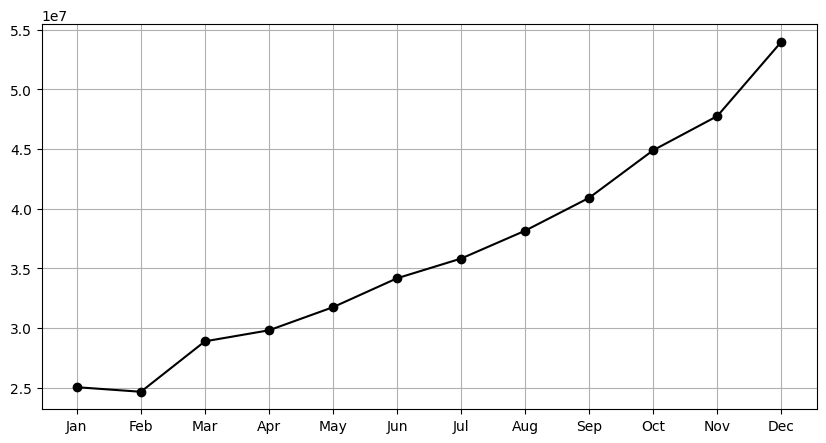

In [108]:
from matplotlib import colors


df['month'] = df['issue_date'].dt.month

monthly_loans = df.groupby('month', as_index=False)['loan_amount'].sum().reset_index()

plt.figure(figsize=(10,5))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(months,monthly_loans['loan_amount'],marker='o',color="black")
plt.grid()
plt.show()
